In [7]:
# Cell 1: Import necessary libraries
import sounddevice as sd
import numpy as np
import librosa
import opensmile
import pandas as pd
from scipy.io.wavfile import write, read
import tempfile
import os
from IPython.display import display, clear_output, HTML, Audio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
# Cell 2: Load and prepare dataset
# Load the dataset
df = pd.read_csv('parkinsons_speech_features.csv')

# Split features and target
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # Last column as target

# Print dataset info
print("Dataset Shape:", df.shape)
print("\nFeature Names:")
print(X.columns.tolist())
print("\nClass Distribution:")
print(y.value_counts())

Dataset Shape: (495, 89)

Feature Names:
['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stddevN

In [9]:
# Cell 3: Complete ModelEvaluator class
class ModelEvaluator:
    def __init__(self):
        self.models = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'SVM': SVC(probability=True, random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42),
            'Neural Network': MLPClassifier(max_iter=1000, random_state=42),
            'KNN': KNeighborsClassifier(),
            'Decision Tree': DecisionTreeClassifier(random_state=42),
            'Naive Bayes': GaussianNB()
        }
        
        self.pca_pipelines = {}
        self.select_pipelines = {}
        
    def create_pipelines(self):
        for name, model in self.models.items():
            # PCA Pipeline
            self.pca_pipelines[name] = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=20)),  # Fixed number of components
                ('classifier', model)
            ])
            
            # SelectKBest Pipeline
            self.select_pipelines[name] = Pipeline([
                ('scaler', StandardScaler()),
                ('select', SelectKBest(f_classif, k=20)),
                ('classifier', model)
            ])
    
    def evaluate_models(self, X, y):
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        results = {'PCA': {}, 'SelectKBest': {}}
        
        # Train and evaluate PCA pipelines
        print("Training and evaluating PCA pipelines...")
        for name, pipeline in self.pca_pipelines.items():
            pipeline.fit(X_train, y_train)
            train_score = pipeline.score(X_train, y_train)
            test_score = pipeline.score(X_test, y_test)
            cv_scores = cross_val_score(pipeline, X, y, cv=5)
            
            results['PCA'][name] = {
                'train_score': train_score,
                'test_score': test_score,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }
        
        # Train and evaluate SelectKBest pipelines
        print("\nTraining and evaluating SelectKBest pipelines...")
        for name, pipeline in self.select_pipelines.items():
            pipeline.fit(X_train, y_train)
            train_score = pipeline.score(X_train, y_train)
            test_score = pipeline.score(X_test, y_test)
            cv_scores = cross_val_score(pipeline, X, y, cv=5)
            
            results['SelectKBest'][name] = {
                'train_score': train_score,
                'test_score': test_score,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }
        
        return results, (X_train, X_test, y_train, y_test)

    def plot_results(self, results):
        plt.figure(figsize=(20, 6))
        
        # Train scores
        plt.subplot(131)
        scores = pd.DataFrame({
            'PCA': [results['PCA'][model]['train_score'] for model in results['PCA']],
            'SelectKBest': [results['SelectKBest'][model]['train_score'] for model in results['SelectKBest']]
        }, index=list(results['PCA'].keys()))
        scores.plot(kind='bar')
        plt.title('Training Scores')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        
        # Test scores
        plt.subplot(132)
        scores = pd.DataFrame({
            'PCA': [results['PCA'][model]['test_score'] for model in results['PCA']],
            'SelectKBest': [results['SelectKBest'][model]['test_score'] for model in results['SelectKBest']]
        }, index=list(results['PCA'].keys()))
        scores.plot(kind='bar')
        plt.title('Test Scores')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        
        # CV scores
        plt.subplot(133)
        scores = pd.DataFrame({
            'PCA': [results['PCA'][model]['cv_mean'] for model in results['PCA']],
            'SelectKBest': [results['SelectKBest'][model]['cv_mean'] for model in results['SelectKBest']]
        }, index=list(results['PCA'].keys()))
        scores.plot(kind='bar')
        plt.title('Cross-Validation Scores')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        
        plt.tight_layout()
        plt.show()

In [10]:
# Cell 4: Define FeatureExtractor class
class FeatureExtractor:
    def __init__(self):
        self.smile_egemaps = opensmile.Smile(
            feature_set=opensmile.FeatureSet.eGeMAPSv02,
            feature_level=opensmile.FeatureLevel.Functionals,
        )
        
    def extract_features(self, audio_path):
        try:
            features = self.smile_egemaps.process_file(audio_path)
            return features
        except Exception as e:
            print(f"Error processing audio: {str(e)}")
            return None

In [11]:
# Cell 5: Modified SingleRecordingClassifier class
class SingleRecordingClassifier:
    def __init__(self, pca_pipelines, select_pipelines, feature_extractor, training_features, duration=10, fs=16000):
        self.duration = duration
        self.fs = fs
        self.pca_pipelines = pca_pipelines
        self.select_pipelines = select_pipelines
        self.feature_extractor = feature_extractor
        self.temp_dir = tempfile.mkdtemp()
        self.audio_path = None
        self.output = widgets.Output()
        self.training_features = training_features
    
    def record_audio(self, _):
        with self.output:
            clear_output(wait=True)
            try:
                print("Recording... Speak now!")
                recording = sd.rec(int(self.duration * self.fs), 
                                 samplerate=self.fs, 
                                 channels=1)
                sd.wait()
                
                self.audio_path = os.path.join(self.temp_dir, "recording.wav")
                write(self.audio_path, self.fs, recording)
                
                clear_output(wait=True)
                self.process_and_display_results()
                
            except Exception as e:
                print(f"Error: {str(e)}")
    
    def align_features(self, extracted_features):
        """Align extracted features with training features"""
        extracted_dict = extracted_features.iloc[0].to_dict()
        aligned_dict = {feature: 0 for feature in self.training_features}
        
        for feature in self.training_features:
            if feature in extracted_dict:
                aligned_dict[feature] = extracted_dict[feature]
        
        return pd.DataFrame([aligned_dict])
    
    def process_and_display_results(self):
        try:
            # Extract features
            features_df = self.feature_extractor.extract_features(self.audio_path)
            
            # Align features with training data
            aligned_features = self.align_features(features_df)
            
            # 1. Display audio
            print("🎵 Your Recording:")
            display(Audio(self.audio_path))
            
            # 2. Display feature heatmap
            print("\n📊 Extracted Features:")
            plt.figure(figsize=(15, 5))
            sns.heatmap(aligned_features, 
                       xticklabels=aligned_features.columns,
                       yticklabels=False,
                       cmap='viridis')
            plt.title("Feature Values Heatmap")
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()
            plt.close()
            
            # 3. Display key features
            print("\n🔑 Key Features (first 5):")
            print(aligned_features.iloc[0][:5].to_string())
            
            # 4. Display all model predictions
            print("\n🎯 Classification Results:")
            print("-" * 50)
            
            all_results = []
            
            # Process predictions
            for pipeline_type, pipelines in [('SelectKBest', self.select_pipelines), 
                                           ('PCA', self.pca_pipelines)]:
                for model_name, pipeline in pipelines.items():
                    try:
                        # Apply full pipeline transformation and prediction
                        pred = pipeline.predict(aligned_features)[0]
                        prob = pipeline.predict_proba(aligned_features)[0]
                        conf = prob[pred] * 100
                        
                        all_results.append({
                            'type': pipeline_type,
                            'model': model_name,
                            'prediction': pred,
                            'confidence': conf,
                            'probability': prob
                        })
                    except Exception as e:
                        print(f"Error with {pipeline_type} - {model_name}: {str(e)}")
                        continue
            
            # Sort by confidence and agreement
            all_results.sort(key=lambda x: (x['confidence'], abs(x['probability'][1] - 0.5)), reverse=True)
            
            # Calculate consensus
            if all_results:
                predictions = [r['prediction'] for r in all_results]
                probabilities = [r['probability'][1] for r in all_results]  # Probability of Parkinson's
                consensus = np.mean(predictions)
                avg_confidence = np.mean([r['confidence'] for r in all_results])
                
                # Display consensus
                consensus_color = 'red' if consensus > 0.5 else 'green'
                consensus_text = 'Parkinson' if consensus > 0.5 else 'Healthy'
                consensus_html = f"""
                <div style='margin: 10px 0; padding: 15px; border-radius: 5px; 
                     background-color: {consensus_color}1a; border: 2px solid {consensus_color};'>
                    <strong>Overall Consensus:</strong><br>
                    <span style='color: {consensus_color}; font-size: 1.2em;'>
                        {consensus_text} (Agreement: {abs(consensus - 0.5) * 200:.1f}%)<br>
                        Average Confidence: {avg_confidence:.1f}%
                    </span>
                </div>
                """
                display(HTML(consensus_html))
                
                # Display individual model results
                results_html = "<div style='margin-top: 10px;'>"
                for result in all_results:
                    result_text = 'Parkinson' if result['prediction'] == 1 else 'Healthy'
                    color = 'red' if result['prediction'] == 1 else 'green'
                    
                    results_html += f"""
                    <div style='margin: 10px 0; padding: 15px; border-radius: 5px; 
                         background-color: {color}1a; border-left: 5px solid {color};'>
                        <strong>{result['type']} - {result['model']}</strong><br>
                        <span style='color: {color}; font-size: 1.1em;'>
                            Prediction: {result_text}<br>
                            Confidence: {result['confidence']:.2f}%
                        </span>
                    </div>
                    """
                
                results_html += "</div>"
                display(HTML(results_html))
            else:
                print("No successful predictions were made.")
            
        except Exception as e:
            print(f"Error in processing: {str(e)}")
            import traceback
            traceback.print_exc()
        
        print("-" * 50)

# Cell 3: Modified ModelEvaluator class


Training and evaluating PCA pipelines...

Training and evaluating SelectKBest pipelines...
Model Performance Comparison:


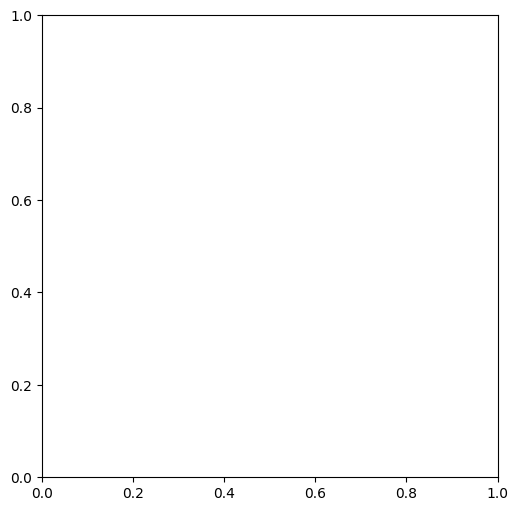

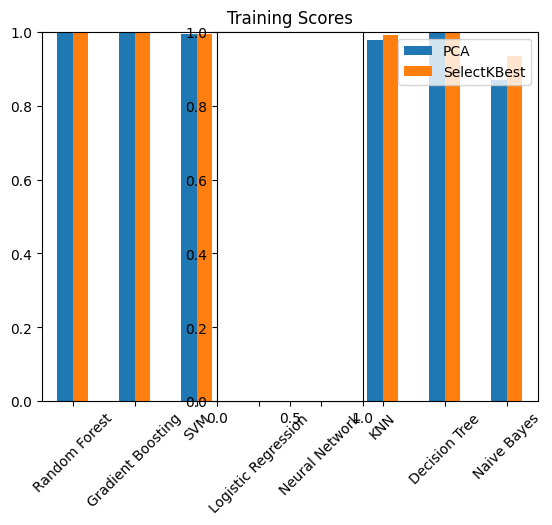

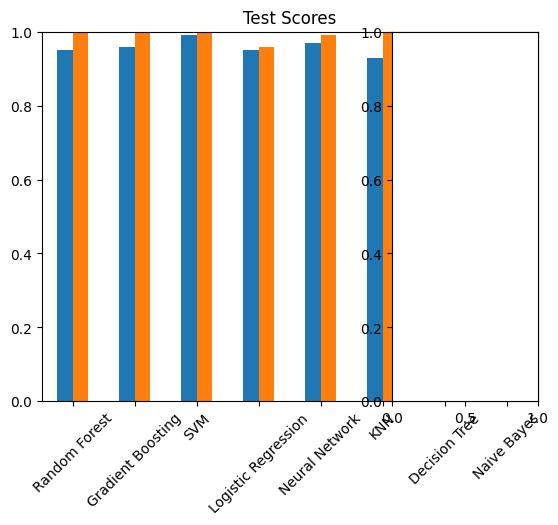

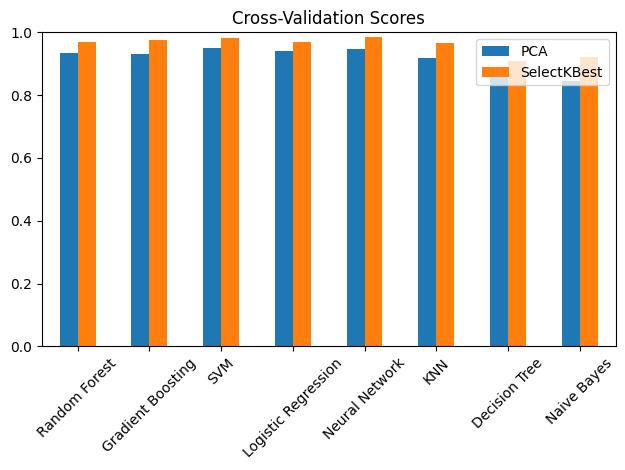

In [12]:
# Cell 6: Rest of the code remains the same
# Initialize evaluator and create pipelines
evaluator = ModelEvaluator()
evaluator.create_pipelines()

# Train models and get results
results, (X_train, X_test, y_train, y_test) = evaluator.evaluate_models(X, y)

# Plot model performance
print("Model Performance Comparison:")
evaluator.plot_results(results)

# Initialize feature extractor
feature_extractor = FeatureExtractor()

# Create classifier with trained models and training features
classifier = SingleRecordingClassifier(
    evaluator.pca_pipelines,
    evaluator.select_pipelines,
    feature_extractor,
    X.columns
)

# Create simple interface
header = widgets.HTML("""
    <div style='padding: 10px; margin-bottom: 20px; 
         background-color: #f8f9fa; border-radius: 5px;'>
        <h2 style='color: #2c3e50; margin-bottom: 10px;'>
            Parkinson's Disease Voice Classification
        </h2>
        <p style='color: #7f8c8d;'>
            Click to record your voice for 5 seconds.
        </p>
    </div>
""")

record_button = widgets.Button(
    description='Record (5 sec)',
    button_style='success',
    icon='microphone'
)

record_button.on_click(classifier.record_audio)

display(widgets.VBox([
    header,
    record_button,
    classifier.output
]))